In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score

In [2]:
df=pd.read_csv("student_scores_clean.csv")

In [3]:
df.isnull().sum()

StudyHours       0
Attendance       0
PreviousGrade    0
FinalScore       0
dtype: int64

In [4]:
df

,StudyHours,Attendance,PreviousGrade,FinalScore
0,0.92,87.2,8.4,9.59
1,4.72,94.0,16.5,16.22
2,4.12,92.7,16.6,14.80
3,1.65,72.5,18.9,10.06
4,4.03,89.4,19.3,14.82
...,...,...,...,...
455,4.93,87.8,12.1,16.20
456,4.35,80.5,11.6,14.01
457,2.03,68.9,10.2,8.50
458,1.95,81.5,16.2,10.67


In [5]:
df.iloc[0:3,10:15]

""
0
1
2


In [6]:
df.loc[6]

StudyHours        3.72
Attendance       91.10
PreviousGrade    15.70
FinalScore       13.92
Name: 6, dtype: float64

In [30]:
vc=df['Attendance'].value_counts()

In [31]:
vc.describe

<bound method NDFrame.describe of Attendance
68.2    4
73.5    4
96.0    4
74.4    4
64.5    4
       ..
82.9    1
66.1    1
75.2    1
94.0    1
83.0    1
Name: count, Length: 279, dtype: int64>

In [9]:
vc.index

Index([ 10.6, 12.43, 11.71,  16.2, 12.35, 12.63, 11.03, 11.84,  8.61,  9.91,
       ...
        10.2,  9.34, 11.07, 11.55, 10.82,  7.15,  11.1, 11.06, 13.46, 11.88],
      dtype='float64', name='FinalScore', length=348)

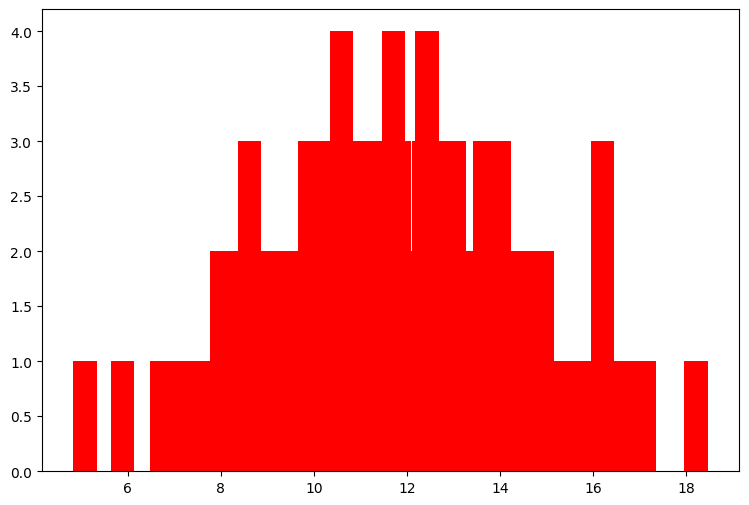

In [10]:
plt.figure(figsize=(9,6))
plt.bar(vc.index,vc,color="red",width=0.5)
plt.show()

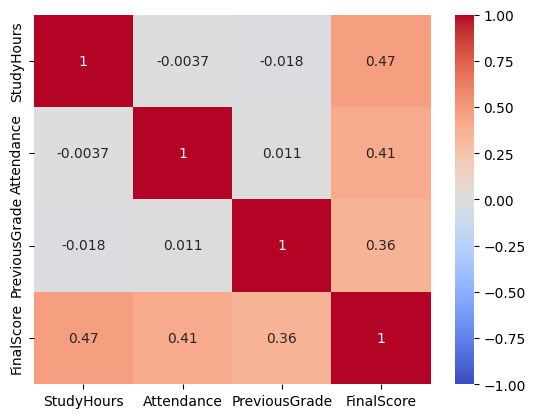

In [11]:
corr=df.corr()
sns.heatmap(corr,annot=True,fmt=".2g",cmap="coolwarm",vmin=-1,vmax=1)
plt.Figure(figsize=(8,7))
plt.show()

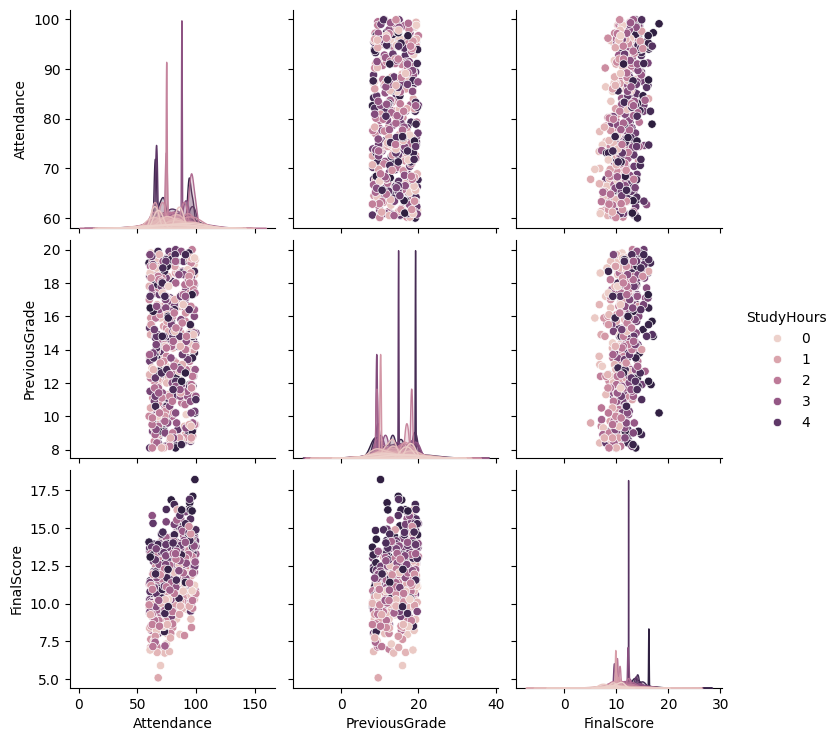

In [12]:
sns.pairplot(data=df,hue="StudyHours")
plt.show()

In [13]:
x=df.drop(columns=['FinalScore'])
y=df['FinalScore']

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)


In [15]:
model=LinearRegression()

In [16]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
y_pred=model.predict(x_test)

In [18]:
y_pred=y_pred.flatten()

In [19]:
r2=r2_score(y_true=y_test,y_pred=y_pred)

In [20]:
r2

0.4542929417538375

In [21]:
mean_absolute_error(y_true=y_test,y_pred=y_pred)

1.1899321956168674

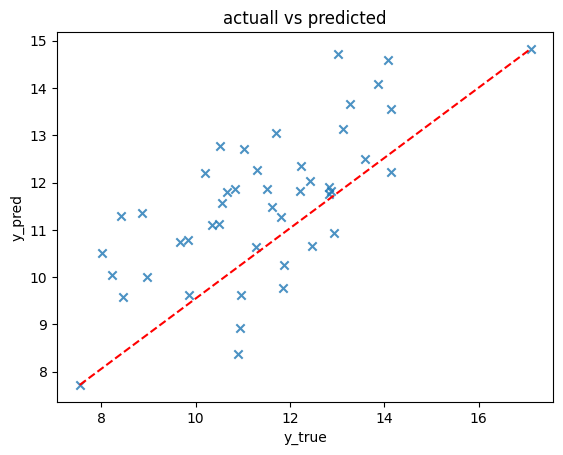

In [22]:
plt.scatter(y_test,y_pred,alpha=0.8,marker="x")
plt.plot([y_test.min(),y_test.max()],[y_pred.min(),y_pred.max()],color='red',linestyle='--')
plt.xlabel("y_true")
plt.ylabel("y_pred")
plt.title("actuall vs predicted")
plt.show()